# Milestone 4 — Honey Yield Predictive Model

**Team:** Stephanie Nord, David Jorgensen, Joshua Amaya
**Course project:** predicting next-day hive weight change from colony sensor history

---

## How to run this notebook

```bash
pip install -r requirements.txt
jupyter nbconvert --to html --execute Milestone_4.ipynb
```

This notebook is designed to run reproducibly from the project repository using the committed `data/honey_model.parquet` dataset. All analyses, model evaluations, tables, and figures are generated at runtime from this shared data source, eliminating reliance on local database files, credentials, or machine-specific paths.

The reproducibility workflow was strengthened for Milestone 4 following feedback from the previous milestone. The current implementation provides a consistent shared data source that allows the complete analytical workflow to be reproduced across team members and computing environments.

## What this milestone delivers

1. **A documented data-preparation process** (Section 2), including a row-count waterfall that documents observations removed during construction of the modeling dataset.
2. **Model development and evaluation** (Section 5), including naive baselines, chronological evaluation, rolling-origin cross-validation, and evaluation of a two-stage modeling approach.
3. **Interpretation of results** (Section 6), including additional analyses that refine findings from Milestone 3.
4. **Preliminary conclusions and recommendations** (Section 7), incorporating the expanded analysis conducted during this milestone.

## How Milestone 4 builds on Milestone 3

Milestone 3 established the initial end-to-end daily modeling pipeline and identified several findings that warranted additional investigation, including the effect of extreme weight changes on model performance and the potential relationship between those observations and beekeeper activity.

For Milestone 4, the pipeline was scaled and made fully reproducible using the complete daily dataset. The evaluation framework was also strengthened through additional baselines, chronological validation, rolling-origin cross-validation, and further examination of extreme observations and event-related variables. These analyses refine several preliminary findings from Milestone 3 rather than replacing the original modeling approach.

The following table summarizes how the expanded Milestone 4 analysis refined the preliminary findings reported in Milestone 3.

| Milestone 3 finding | Milestone 4 refinement | Section |
|---|---|---|
| Routine-only modeling produced R² = 0.216 under the initial evaluation approach. | Expanded evaluation showed that performance varies depending on how routine observations are defined and evaluated, emphasizing the importance of evaluating models on the full deployment population. | 5.3 |
| Extreme weight changes showed limited association with the initially examined beekeeper-event variables. | Additional examination of publisher-provided flags and event variables identified potential relationships that warrant further investigation. | 3.5 |
| Initial event-distance analysis identified few extremes occurring within one day of logged events. | Examination of the source fields identified inconsistent event-distance units across hives; normalization produced revised estimates for proximity to logged events. | 3.3 |
| Gradient Boosting outperformed Random Forest in the initial comparison. | Expanded evaluation across folds and random seeds provided a more robust comparison of the two ensemble approaches. | 5.5 |

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd() / "src"))

from honeymodel import data, evaluation as ev, features, models

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

RESULTS = Path("results")

def show(name, **kwargs):
    # Render a table produced by scripts/run_*.py.
    return pd.read_csv(RESULTS / name, **kwargs)

model_df = data.add_season(data.load_model_table())
print(f"modelling rows : {len(model_df):,}")
print(f"hives          : {model_df.hive_id.nunique()}")
print(f"date range     : {model_df.measurement_date.min().date()} to {model_df.measurement_date.max().date()}")
print(f"columns        : {model_df.shape[1]}")

modelling rows : 26,215
hives          : 78
date range     : 2019-06-25 to 2022-12-30
columns        : 72


`load_model_table` asserts the published shape on every load — 26,215 rows across 78 hives,
no duplicate hive-days — so a silently altered snapshot cannot reach the analysis below.

## 2. Data Preparation Process

### 2.1 Source and provenance

> Senger, D., Gruber, C., Kluss, T., & Johannsen, C. (2024). Weight, temperature and
> humidity sensor data of honey bee colonies in Germany, 2019–2022. *Data in Brief, 52*,
> 110015. https://doi.org/10.1016/j.dib.2023.110015
>
> Dataset: https://doi.org/10.5281/zenodo.10407693

78 colonies across Germany, June 2019 – December 2022, instrumented under a
citizen-science project. Each hive carries five internal temperature sensors, an external
temperature sensor, a combined temperature/humidity/pressure sensor, and a scale.
Beekeepers logged inspections and interventions through the project's own web app.

**Dataset provenance clarification.** During Milestone 3, the primary dataset was described as “HOBOS,” and the observation logs were attributed to “USDA Tucson.” As the project expanded to the complete daily archive for Milestone 4, further review of the source documentation clarified that the primary data are from the German citizen-science project described by Senger et al. (2024), and the beekeeper observation logs originate from that project. The source information and citation have been updated accordingly.

**Licensing.** The Zenodo record is open access but declares no license — the DataCite
`rightsList` is empty. We commit a derived daily-grain table (about 0.05% of the 5.6 GB
archive) with full attribution so that this notebook can be reproduced without
credentials, and have written to the corresponding author to confirm the intended terms.
`data/README.md` records the fallback if redistribution turns out to be restricted.

### 2.2 Publisher preprocessing

Understanding the preprocessing performed by the dataset publishers is important for interpreting the derived weight variables and subsequent modeling results. From the paper's methods:

- **Range filters.** Weights above 150 kg or below −50 kg, temperatures above 85 °C or
  below −40 °C, and humidity outside 0–100% were excluded.
- **Rate filter.** The weight series was differentiated and changes above **0.3 kg per
  minute** excluded, because such "sudden drastic changes in the weight […] are usually
  induced by activities by the beekeeper."
- **Aggregation.** Raw readings arrive every 5–10 seconds; the minute series is a median,
  and the hourly and daily series are averages of the minute series.

Two consequences matter a great deal, and Section 3.5 quantifies the first:

1. The rate filter produced a **second weight column**. `weight_kg` keeps every jump;
   `weight_kg_noOutlier` is the cumulative sum of the same deltas with flagged jumps
   zeroed. Milestone 3 built its target from `weight_kg` — the series that still contains
   the events the publishers attribute to beekeeper handling.
2. `end_of_day_weight_kg` is a **misnomer**: the daily value is the mean of the day's
   minute readings, not the last one. The target is a change in daily *mean* weight. The
   column name is retained for continuity with the Milestone 3 schema and is corrected in
   the documentation.

### 2.3 Ingestion and grain

The publisher's daily files come in two arrangements, and only one of them is a genuine
archive of the whole record:

| dataset | files | rows | hives | what it is |
|---|---|---|---|---|
| `years` | 78 | 29,172 | 78 | the full 2019–2022 daily archive |
| `events` | 191 | 12,538 | 55 | 3-month windows either side of a swarming or colony-death event |

The `events` files re-slice hive-days that `years` already contains: only 948 of its
hive-days (3.2%) are new, and it holds 527 internal duplicates. The pipeline ingests
`years` only.

Milestone 3 developed and validated the initial pipeline using the available subset of daily files. For Milestone 4, the workflow was expanded to the complete `years` archive, producing 29,172 daily observations across all 78 hives. The hive count, temporal coverage, and 1.7% extreme-event rate reported below therefore reflect the complete daily archive.

Typing uses `TRY_CAST` with `NULLIF(col, 'NA')` throughout (`sql/02_clean.sql`), and the
grain — one row per hive per day — is asserted in `scripts/build_honey_model.py` *before*
any window function runs, rather than assumed.

### 2.4 Filtering: a row-count waterfall

In [2]:
waterfall = show("data_preparation_waterfall.csv")
display(waterfall)
print(f"total rows dropped: {waterfall.rows_dropped.sum():,}  "
      f"({100 * waterfall.rows_dropped.sum() / waterfall.rows_remaining.iloc[0]:.1f}% of ingested rows)")

,gate,rows_remaining,rows_dropped
0,"daily rows ingested (years, interval=d)",29172,0
1,has a previous consecutive day,28078,1094
2,has a next consecutive day,27110,968
3,all three weights present,27092,18
4,all three weights > 0 (Milestone 3 guard),26215,877


total rows dropped: 2,957  (10.1% of ingested rows)


The row-count waterfall documents the reduction from 29,172 daily observations to 26,215 modeling observations. Of the 2,957 excluded rows, 1,094 lack a consecutive previous-day observation, 968 lack a consecutive next-day observation, 18 are missing one of the three required weight values, and 877 do not satisfy the positive-weight criterion.

### 2.5 Missingness

In [3]:
sensor_columns = features.SENSOR_FEATURES
missing = features.summarise_missingness(model_df, sensor_columns)
display(missing)

,column,missing,missing_pct
0,avg_humidity,9271,35.37
1,avg_pressure,8118,30.97
2,avg_internal_temp_4,7328,27.95
3,avg_internal_temp_1,6610,25.21
4,avg_internal_temp_3,6538,24.94
5,avg_outside_temp,6081,23.20
6,avg_internal_temp_2,6066,23.14


The sensor variables contain substantial missingness, ranging from approximately 23% to 35% across the modeling dataset. Because removing all observations with missing sensor values would result in considerable data loss, the modeling workflow uses approaches that preserve observations while preventing imputation from introducing information across independent hives.

For models requiring complete feature values, forward-fill imputation is performed independently within each hive after observations are ordered chronologically by `measurement_date`. Restricting imputation by `hive_id` prevents measurements from one colony from being propagated into another colony. Missingness indicators are also retained for imputed sensor variables, allowing the models to distinguish observed measurements from values introduced through imputation.

When supported by the modeling algorithm, missing values are retained rather than imputed. `HistGradientBoostingRegressor` and LightGBM can handle missing values natively, allowing these models to use the available sensor information without requiring the removal of incomplete observations or additional imputation. Together, these approaches preserve as much of the available data as possible while maintaining separation between hives and reducing the potential for artifacts introduced during preprocessing.

### 2.6 Leakage controls

In [4]:
# honey_model deliberately ships columns that are only knowable after the prediction date
# -- the extreme-event investigation needs them. They must never reach a feature matrix.
print(f"{len(features.FORBIDDEN_COLUMNS)} forbidden columns, including:")
for column in sorted(features.FORBIDDEN_COLUMNS)[:6]:
    print(f"  {column}")

# Negative test: asking for one must fail, not silently produce a perfect model.
try:
    features.build_feature_matrix(model_df, feature_set=["previous_day_weight_kg", "next_day_weight_kg"])
except features.LeakageError as error:
    print(f"\nLeakageError raised as intended:\n  {error}")

24 forbidden columns, including:
  days_to_next_observation
  died_next_dif
  extreme_relative_flag
  extreme_weight_change_flag
  extreme_weight_change_flag_10
  extreme_weight_change_flag_3

LeakageError raised as intended:
  these columns are only knowable after the prediction date, or are derived from the label, and must not be used as features: ['next_day_weight_kg']


Because `next_day_weight_kg` and other post-prediction variables contain information that would not be available at prediction time, these variables are explicitly excluded from the feature matrix to prevent target leakage. The modeling pipeline programmatically enforces this restriction, and a negative test confirms that prohibited variables cannot be incorporated as predictors. This safeguard helps ensure that reported model performance reflects information that would realistically be available when generating a next-day prediction.

## 3. Data Quality and Extreme-Event Analysis

Milestone 3 separated the target distribution into routine observations (98.3%) and extreme weight changes (1.7%; |Δ| > 5 kg, 445 observations), demonstrating that a relatively small number of extreme observations substantially influence model performance. This distinction remains an important component of the Milestone 4 analysis.

For Milestone 4, the extreme-event investigation was aligned directly with the 445 daily observations identified in the final modeling dataset. Earlier exploratory analysis also examined publisher-defined outlier indicators at the minute-level grain; however, those indicators represent a different observation frequency and outlier definition than the daily prediction target. The analyses below therefore focus specifically on the daily extreme observations used in the predictive modeling workflow.

### 3.1 Physically implausible weights

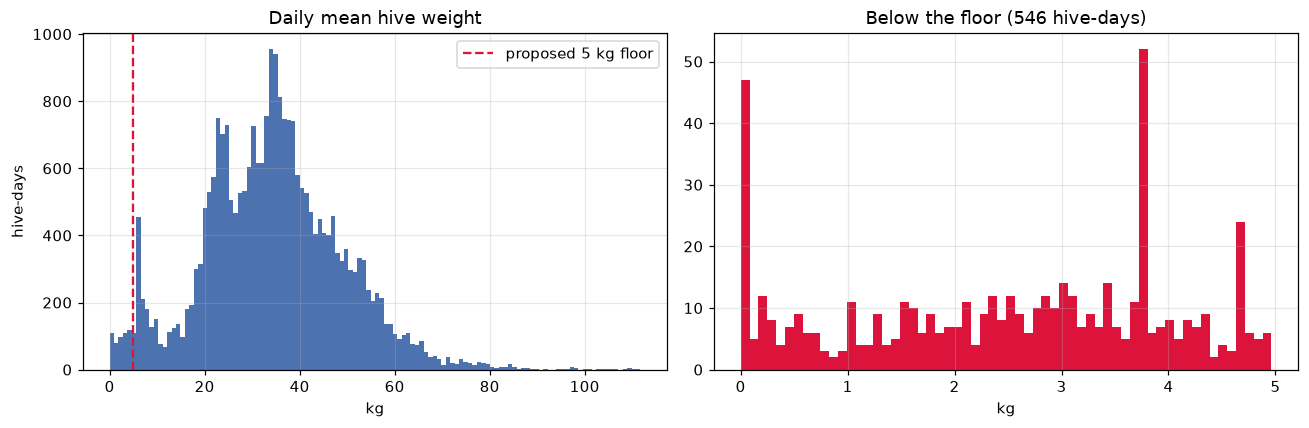

minimum weight in the modelling table : 0.0005 kg
mean weight                           : 34.3 kg
rows flagged implausible              : 597


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(model_df.end_of_day_weight_kg, bins=120, color="#4c72b0", edgecolor="none")
axes[0].axvline(5, color="crimson", linestyle="--", label="proposed 5 kg floor")
axes[0].set(title="Daily mean hive weight", xlabel="kg", ylabel="hive-days")
axes[0].legend()

low = model_df[model_df.end_of_day_weight_kg < 5]
axes[1].hist(low.end_of_day_weight_kg, bins=60, color="crimson", edgecolor="none")
axes[1].set(title=f"Below the floor ({len(low):,} hive-days)", xlabel="kg")
plt.tight_layout(); plt.show()

print(f"minimum weight in the modelling table : {model_df.end_of_day_weight_kg.min():.4f} kg")
print(f"mean weight                           : {model_df.end_of_day_weight_kg.mean():.1f} kg")
print(f"rows flagged implausible              : {int(model_df.implausible_weight_flag.sum()):,}")

A transition from a typical hive weight to a near-zero reading can generate a very large calculated daily weight change that may reflect measurement or processing artifacts rather than biological colony change.

### 3.2 Data-quality characteristics of extreme observations

In [6]:
display(show("extremes_attribution.csv"))

,explanation,extremes_flagged,pct_of_extremes,total_extremes
0,implausible weight (below 5 kg floor),19,4.27,445
1,hive-local robust outlier (>5 MAD),122,27.42,445
2,drop-then-recovery (dropout / re-tare),26,5.84,445
3,any data-quality flag,138,31.01,445


The diagnostic analysis identified at least one data-quality flag for 138 of the 445 extreme observations (31.0%). Of the extreme observations, 4.3% involved hive weights below the proposed 5 kg plausibility threshold, 27.4% were identified as hive-local robust outliers using the >5 MAD criterion, and 5.8% exhibited a drop-then-recovery pattern consistent with a possible sensor dropout or scale re-tare. Because these diagnostic categories may overlap, they should not be interpreted as mutually exclusive causes of extreme weight change. The remaining observations were not identified by the data-quality criteria evaluated here; however, the available evidence is insufficient to attribute those observations to a specific biological, environmental, or beekeeper-related mechanism. These results indicate that data-quality anomalies contribute to a meaningful subset of extreme observations and should be considered when interpreting model performance.

### 3.3 Proximity to logged beekeeper events — and a unit defect in the source

In [7]:
display(show("event_distance_units.csv"))

,column,hives_in_days,hives_in_seconds,hives_undetermined
0,honey_last_dif,62,16,41
1,honey_next_dif,58,20,54
2,feeding_last_dif,62,16,37
3,feeding_next_dif,49,29,46
4,swarming_last_dif,71,7,65
5,swarming_next_dif,71,7,63
6,treatment_last_dif,73,5,51
7,treatment_next_dif,62,16,55
8,died_last_dif,75,3,68
9,died_next_dif,75,3,72


The published *_last_dif and *_next_dif variables describe the temporal distance between sensor observations and logged beekeeper events. Examination of consecutive daily observations indicated that these variables are not represented in a consistent unit across the dataset. For some records, the values advance by approximately 1 per day, whereas others advance by approximately 86,400, consistent with seconds per day. Consequently, direct threshold comparisons applied to the unstandardized variables may underestimate event proximity for records represented in seconds.

To improve comparability, the Milestone 4 workflow evaluates the units represented within these event-distance variables and converts identifiable values to a common daily scale. This analysis also revealed that unit representation may change within individual hive histories, meaning that per-hive normalization does not completely resolve the inconsistency. The resulting proximity estimates should therefore be interpreted as exploratory rather than exact measures of beekeeper-event timing.

In [8]:
proximity = show("extremes_event_proximity.csv")
comparison = proximity.pivot(index="event", columns="group",
                             values=["pct_within_1_day", "pct_within_7_days"]).round(2)
display(comparison)

pct_within_1_day         pct_within_7_days        
group              extreme routine           extreme routine
event                                                       
died                  1.04    1.85              1.04    2.74
feeding              13.21    8.69             23.02   13.60
honey                 7.81    8.68             15.99   15.11
queencell            10.65    9.97             16.57   12.40
swarming              1.55    4.07              1.55    5.45
treatment            10.29    7.41             19.85   10.91

After normalization, extreme observations showed somewhat greater proximity to recorded feeding and treatment events than routine observations. Within one day, 13.2% of extreme observations were near a recorded feeding event compared with 8.7% of routine observations, while 10.3% of extreme observations were near a treatment event compared with 7.4% of routine observations. Other event categories showed smaller differences or lower proximity among extreme observations.

These results do not demonstrate that beekeeper activity caused the extreme weight changes. Rather, they suggest that certain recorded activities, particularly feeding and treatment, may be associated with some extreme observations and warrant further investigation. Interpretation is limited by the inconsistent units in the source event-distance variables and by the completeness and timing of beekeeper-entered records. Accordingly, event proximity is treated as supporting exploratory evidence rather than a definitive explanation for the extreme-event population.

### 3.4 When do extremes happen?

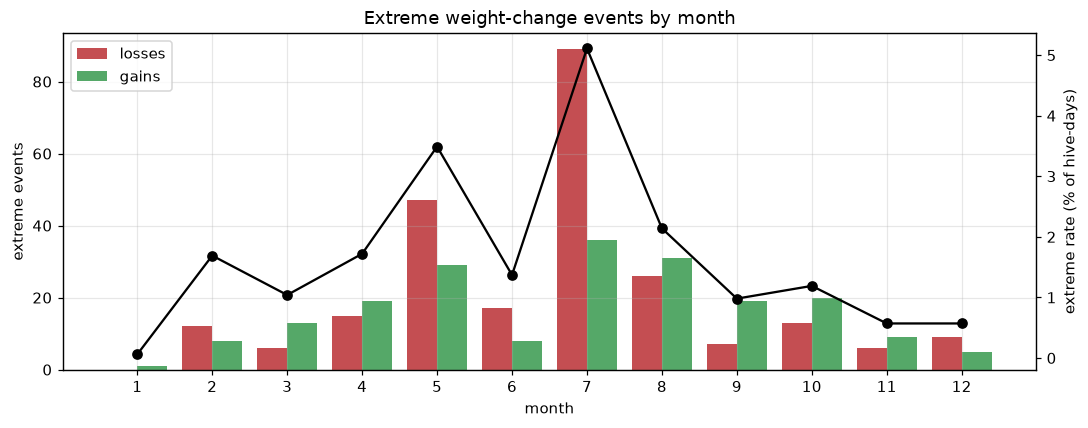

,month,hive_days,extremes,extreme_losses,extreme_gains,extreme_rate_pct
0,1,1624,1,0,1,0.06
1,2,1186,20,12,8,1.69
2,3,1828,19,6,13,1.04
3,4,1978,34,15,19,1.72
4,5,2179,76,47,29,3.49
5,6,1826,25,17,8,1.37
6,7,2447,125,89,36,5.11
7,8,2659,57,26,31,2.14
8,9,2652,26,7,19,0.98
9,10,2765,33,13,20,1.19


In [9]:
monthly = show("extremes_by_month.csv")
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly.month - 0.2, monthly.extreme_losses, width=0.4, label="losses", color="#c44e52")
ax.bar(monthly.month + 0.2, monthly.extreme_gains, width=0.4, label="gains", color="#55a868")
ax2 = ax.twinx(); ax2.plot(monthly.month, monthly.extreme_rate_pct, color="black", marker="o", label="rate %")
ax2.set_ylabel("extreme rate (% of hive-days)"); ax2.grid(False)
ax.set(xlabel="month", ylabel="extreme events", title="Extreme weight-change events by month",
       xticks=range(1, 13))
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()
display(monthly)

The extreme-event analysis reveals a pronounced seasonal pattern. Extreme observations occur most frequently during the warmer months, with July exhibiting the highest extreme-event rate (5.11%), followed by May (3.49%), while January shows a substantially lower rate (0.06%). July also contains considerably more extreme losses than gains (89 versus 36).

The concentration of extreme weight losses during the summer months suggests that these observations may reflect processes with a seasonal component. Potential explanations include beekeeper management activities such as honey harvesting, seasonal changes in colony dynamics, environmental conditions, or combinations of these factors. Because the available data do not independently verify the cause of each extreme observation, the seasonal pattern should be interpreted as evidence for further investigation rather than attribution to a specific mechanism.

This finding expands the Milestone 3 analysis by demonstrating that extreme observations are not distributed uniformly throughout the year. Incorporating seasonality into subsequent modeling and event analysis may therefore improve characterization of these relatively rare observations.

### 3.5 Sensitivity of extreme-event identification to weight-series selection

In [10]:
display(show("extremes_weight_series.csv"))

,modelling_rows,extremes_weight_kg,extremes_weight_kg_noOutlier,extremes_removed_by_cleaning,target_correlation
0,26215,445.0,101.0,419.0,0.1243


The published dataset provides both the original weight_kg series and a corresponding weight_kg_noOutlier series in which abrupt changes identified by the publisher's rate-based filtering procedure have been adjusted. Applying the same daily modeling-grain construction to the two series produces substantially different extreme-event populations: 445 extreme observations are identified using weight_kg, compared with 101 when using weight_kg_noOutlier. Of the original extreme observations, 419 are affected by the publisher's filtering procedure.

This difference demonstrates that extreme-event identification is highly sensitive to the choice of weight series. The publisher documentation indicates that abrupt weight changes exceeding the rate threshold are frequently associated with beekeeper activity; however, the filtering procedure does not establish the cause of each individual extreme observation. The large reduction in extreme observations therefore provides additional evidence that management-related or measurement-related abrupt changes may contribute substantially to the extreme-event population, but it does not permit direct causal attribution.

The project retains weight_kg for the primary target to maintain continuity with the modeling framework established in Milestone 3 and to avoid automatically removing potentially meaningful biological or management-related changes. The alternative series is instead used as a sensitivity analysis. Comparing results across the two representations helps quantify how publisher-defined filtering decisions influence the target distribution and subsequent model performance.

### 3.6 Threshold sensitivity

In [11]:
display(show("threshold_sweep.csv"))

,definition,extremes,extreme_pct,routine_rows,routine_mae_oracle_gated,routine_r2_oracle_gated,classifier_pr_auc,classifier_roc_auc,pr_auc_lift_over_no_skill
0,absolute 3 kg,834,3.181,25381,0.2387,0.2510,0.3154,0.8676,8.82
1,absolute 5 kg,445,1.698,25770,0.3005,0.2274,0.2276,0.8477,12.91
2,absolute 7 kg,281,1.072,25934,0.3303,0.2107,0.1833,0.8472,15.70
3,absolute 10 kg,178,0.679,26037,0.3565,0.2009,0.1435,0.8582,18.15
4,hive-relative 5 MAD,2873,10.959,23342,0.1425,0.1691,0.5230,0.8579,4.34


The ±5 kg threshold established in Milestone 3 provided a consistent operational definition of an extreme weight change. Because this absolute threshold applies equally across hives of substantially different sizes, Milestone 4 evaluates the sensitivity of the results to alternative thresholds and a hive-relative definition.

The threshold sensitivity analysis demonstrates a consistent trade-off between event frequency and classification performance. Lower absolute thresholds identify more positive observations and produce higher classifier PR-AUC, while higher thresholds define increasingly rare events. The hive-relative definition (>5 MAD from each hive's own weight-change distribution) identifies 10.96% of hive-days and achieves the highest PR-AUC (0.523), suggesting that a hive-specific definition may better capture unusual changes relative to each colony's typical variability.

The ±5 kg threshold is retained in the current analysis for continuity and comparability with Milestone 3. However, the performance of the hive-relative definition suggests that adaptive thresholds may be valuable for future development of an operational early-warning system.

## 4. Validation Framework

Milestone 4 expands the validation framework established in Milestone 3 to provide a more robust assessment of model generalization. The updated evaluation incorporates date-based chronological splitting, rolling-origin cross-validation, repeated model evaluation where appropriate, comparison with naive baselines, and performance assessment on the complete test distribution. These additions allow model performance to be evaluated across multiple time periods while preserving the temporal structure of the data.

### 4.1 Date-based chronological splitting

The chronological train-test split was refined for Milestone 4 to operate on measurement dates rather than row positions. Because multiple hives contribute observations on the same calendar date, a row-index split can place observations from a single date in both the training and test sets. Although the observations represent different hives, separating the datasets at a date boundary provides a clearer temporal distinction between model development and evaluation.

The updated `date_chronological_split` function therefore partitions observations using the measurement date itself. An integrity check verifies that the latest training date precedes the earliest testing date `(max(train_date) < min(test_date))`, ensuring that the evaluation period occurs entirely after the training period.

In [12]:
folds = ev.rolling_origin_cv(model_df, n_splits=4, horizon_months=6, min_train_months=12)
display(pd.DataFrame([f.describe() for f in folds]))

for fold in folds:  # the assertion each fold already passed at construction
    ev.assert_split_integrity(model_df, fold)
print("split integrity: every fold's training data ends strictly before its test data begins")

,fold,n_train,n_test,train_end,test_start,test_end
0,fold_1_2020-12-25,9278,4043,2020-12-24,2020-12-25,2021-06-24
1,fold_2_2021-06-25,13321,4525,2021-06-24,2021-06-25,2021-12-24
2,fold_3_2021-12-25,17846,4376,2021-12-24,2021-12-25,2022-06-19
3,fold_4_2022-06-25,22222,3867,2022-06-19,2022-07-05,2022-12-24


split integrity: every fold's training data ends strictly before its test data begins


### 4.2 Rolling-origin cross-validation

To evaluate model performance across multiple time periods, Milestone 4 uses rolling-origin cross-validation with four expanding-window folds. For each fold, the training set includes all observations available up to the evaluation boundary, and the subsequent six months are reserved for testing. This approach preserves the temporal ordering of the data while allowing model performance to be assessed across different seasonal periods. Compared with relying on a single chronological split, rolling-origin validation provides a more robust estimate of model generalization and helps identify variation in predictive performance over time.

### 4.3 Naive baselines

Naive baseline models provide reference points for determining whether the predictive models improve meaningfully upon simple forecasting strategies. Because the target has an overall mean near zero (0.002 kg), several baseline approaches were evaluated across the same four rolling-origin folds, including prediction of zero, the training-set mean, hive-specific means, hive-month means, and persistence based on the previous day's change.

In [13]:
baselines = show("baselines.csv")
display(ev.fold_summary(baselines).round(4))

,model,folds,mae_mean,mae_sd,rmse_mean,rmse_sd,r2_mean,r2_sd,n
0,predict_zero,4,0.5128,0.0782,1.7425,0.2017,-0.0029,0.0028,16811
1,train_mean,4,0.5157,0.0753,1.7431,0.2020,-0.0036,0.0034,16811
2,hive_mean,4,0.5466,0.0817,1.7504,0.2037,-0.0119,0.0075,16811
3,hive_month_mean,4,0.5862,0.0848,1.7916,0.2223,-0.0594,0.0377,16811
4,persistence,4,0.5974,0.0569,2.1681,0.1983,-0.5825,0.3263,16811


Among the evaluated baselines, predicting zero produced the lowest mean MAE (0.513 kg), making it the strongest naive benchmark for subsequent model comparisons. The persistence baseline, which predicts the next change using the previous day's change, produced a higher mean MAE (0.597 kg) and negative mean R² (−0.583). This indicates that simply carrying the previous day's weight change forward does not provide an effective prediction strategy at the daily grain.

## 5. Models

All candidate models are evaluated using the same rolling-origin cross-validation framework described above. In addition to MAE, RMSE, and R², model performance is summarized using a skill score representing the percentage reduction in MAE relative to the strongest naive baseline. Positive skill scores indicate improvement over the baseline, while negative values indicate that the model did not outperform the reference prediction strategy. Using a common validation framework and baseline allows performance differences among candidate models to be compared consistently.

### 5.1 The model board

In [14]:
summary = show("model_summary.csv")
display(summary.round(4))

,model,folds,mae_mean,mae_sd,rmse_mean,rmse_sd,r2_mean,r2_sd,n,skill_mean,skill_sd
0,predict_zero,4,0.5128,0.0782,1.7425,0.2017,-0.0029,0.0028,16811,NaN,NaN
1,train_mean,4,0.5157,0.0753,1.7431,0.2020,-0.0036,0.0034,16811,NaN,NaN
2,history / HistGB,4,0.5423,0.0777,1.6980,0.1338,0.0359,0.1301,16811,-0.0614,0.0894
3,hive_mean,4,0.5466,0.0817,1.7504,0.2037,-0.0119,0.0075,16811,NaN,NaN
4,history+sensors / HistGB,4,0.5667,0.0831,1.7042,0.1526,0.0305,0.1238,16811,-0.1105,0.1221
5,hive_month_mean,4,0.5862,0.0848,1.7916,0.2223,-0.0594,0.0377,16811,NaN,NaN
6,persistence,4,0.5974,0.0569,2.1681,0.1983,-0.5825,0.3263,16811,NaN,NaN
7,history+sensors / RF,4,0.6695,0.0949,2.0783,0.2687,-0.4699,0.4108,16811,-0.3117,0.1309
8,M3 features / GB,4,0.7833,0.1981,2.5111,0.5713,-1.1567,0.7625,16811,-0.5256,0.3090
9,M3 features / RF,4,0.9769,0.1504,2.4982,0.5066,-1.1264,0.7115,16811,-0.9136,0.2082


The rolling-origin evaluation demonstrates that model performance varies substantially across feature sets and algorithms. Among the learned single-stage models, the history-only HistGradientBoosting model produced the strongest overall performance, with a mean MAE of 0.542 kg, RMSE of 1.698 kg, and R² of 0.036 across the four validation folds. Although its MAE did not improve upon the predict-zero baseline (MAE = 0.513 kg), it achieved a lower RMSE than the baseline (1.698 kg compared with 1.743 kg) and a small positive mean R².

The difference between the MAE and RMSE results provides additional insight into model behavior. The near-zero target distribution makes prediction of zero a competitive strategy for minimizing absolute error across routine observations. In contrast, RMSE places greater weight on larger prediction errors, and the lower RMSE of the history-only HistGradientBoosting model suggests that it provides some predictive value for larger deviations even though it does not improve overall MAE.

Models using the original Milestone 3 feature configuration produced weaker performance under the expanded rolling-origin validation framework, with mean MAE values of 0.783 kg for Gradient Boosting and 0.977 kg for Random Forest and negative mean R² values. These results should not be interpreted as invalidating the earlier analysis. Rather, the expanded evaluation demonstrates that performance estimates are sensitive to the validation strategy, preprocessing decisions, and evaluation population. The Milestone 4 framework therefore provides a more conservative assessment of how well the models generalize across multiple future time periods.

### 5.2 Final-fold model evaluation

The model comparison above is generated through `scripts/run_evaluation.py`. To demonstrate the complete modeling workflow directly within this notebook, the strongest-performing learned configuration is refit and evaluated using the final validation fold. This provides a reproducible example of model training and evaluation using the same preprocessing and temporal-validation framework applied throughout the analysis.

In [15]:
matrix = features.build_feature_matrix(model_df, feature_set="history", impute="none")
fold = folds[-1]
X_train, y_train = matrix.X.iloc[fold.train_index], matrix.y.iloc[fold.train_index]
X_test, y_test = matrix.X.iloc[fold.test_index], matrix.y.iloc[fold.test_index]

winner = models.make_regressor("hist_gb", seed=42).fit(X_train, y_train)
predictions = winner.predict(X_test)

metrics = ev.regression_metrics(y_test, predictions)
naive_mae = ev.best_baseline_mae(baselines, fold.name)
print(f"fold          : {fold.name}  ({fold.test_start.date()} to {fold.test_end.date()}, n={metrics['n']:,})")
print(f"MAE           : {metrics['mae']:.4f} kg   (best naive: {naive_mae:.4f})")
print(f"RMSE          : {metrics['rmse']:.4f} kg")
print(f"R2            : {metrics['r2']:.4f}")
print(f"skill vs naive: {ev.skill_score(metrics['mae'], naive_mae):+.1%}")

fold          : fold_4_2022-06-25  (2022-07-05 to 2022-12-24, n=3,867)
MAE           : 0.4579 kg   (best naive: 0.4536)
RMSE          : 1.6473 kg
R2            : 0.1350
skill vs naive: -1.0%


### 5.3 Comparison of modeling frameworks

In [16]:
framings = show("framings.csv")
table = (framings.groupby(["framing", "honest_label"])[["mae", "rmse", "r2", "skill_vs_naive"]]
         .mean().round(4).reset_index().sort_values("mae"))
display(table)

,framing,honest_label,mae,rmse,r2,skill_vs_naive
0,"routine only, oracle-gated",UPPER BOUND - test rows selected using the label,0.3151,0.6500,0.1544,0.3797
3,"two-stage, unfiltered test (hard gate)",deployable,0.4794,1.7016,0.0435,0.0586
2,"two-stage, unfiltered test (blended)",deployable,0.5157,1.6653,0.0778,-0.0119
1,"single regressor, all data",realistic,0.5667,1.7042,0.0305,-0.1105


To evaluate the influence of extreme observations on model performance, four modeling frameworks were compared using the rolling-origin validation procedure. These frameworks distinguish between evaluation restricted to routine observations, two-stage approaches that first classify potential extreme events, and a single-regressor approach evaluated across the complete target distribution.

The routine-only framework produced the lowest MAE (0.315 kg) and highest R² (0.154); however, this result should be interpreted as an upper-bound estimate because routine test observations are identified using the observed target value. In a prospective prediction setting, the extreme status of the next-day observation would not be known in advance. Therefore, this framework is useful for characterizing predictability within routine observations but does not represent deployable performance.

The two-stage hard-gated framework addresses this limitation by first classifying each observation as routine or extreme and then routing the observation to the corresponding regression model. When evaluated on the complete, unfiltered test distribution, this approach achieved an MAE of 0.479 kg, RMSE of 1.702 kg, and R² of 0.044. Its 5.9% improvement in MAE relative to the strongest naive baseline represents the best deployable MAE performance among the evaluated frameworks.

The blended two-stage approach achieved a higher R² (0.078) but did not improve upon the naive baseline in MAE, while the single-regressor approach produced the weakest performance of the deployable configurations. Collectively, these results suggest that explicitly modeling extreme-event status may provide a modest improvement in next-day prediction performance at the daily grain, although overall predictive performance remains limited.

### 5.4 The extreme-event classifier

In [17]:
classifier = show("classifier.csv")
display(classifier.round(4))
print(f"mean PR-AUC {classifier.pr_auc.mean():.3f} against a no-skill rate of "
      f"{classifier.pr_auc_no_skill.mean():.3f}  ->  {classifier.pr_auc_lift.mean():.1f}x lift")

,fold,pr_auc,roc_auc,positive_rate,pr_auc_no_skill,pr_auc_lift
0,fold_1_2020-12-25,0.1656,0.8059,0.0096,0.0096,17.1637
1,fold_2_2021-06-25,0.1661,0.8537,0.0170,0.0170,9.7585
2,fold_3_2021-12-25,0.1783,0.7986,0.0169,0.0169,10.5467
3,fold_4_2022-06-25,0.3097,0.8529,0.0184,0.0184,16.8666


mean PR-AUC 0.205 against a no-skill rate of 0.015  ->  13.6x lift


Extreme weight changes represent approximately 1.7% of the daily observations, creating a substantial class imbalance. Under this distribution, overall classification accuracy would provide limited information because a model predicting every observation as routine would achieve approximately 98.3% accuracy. Precision-recall area under the curve (PR-AUC) is therefore emphasized because it evaluates the classifier's ability to identify the relatively rare extreme observations. Performance is compared with a no-skill PR-AUC equal to the positive-class prevalence within each validation fold.

Across the four rolling-origin validation folds, PR-AUC ranged from 0.166 to 0.310, compared with no-skill baselines ranging from 0.010 to 0.018. The mean PR-AUC was 0.205, approximately 13.6 times the mean no-skill rate. ROC-AUC ranged from approximately 0.80 to 0.85 across the folds. These results indicate that the available predictors contain information useful for distinguishing observations associated with extreme next-day weight changes. However, classification performance varies across validation periods, and these results do not establish the underlying cause of the extreme events. The classifier is therefore best interpreted as identifying elevated risk of an extreme next-day observation rather than predicting a specific biological or beekeeper-related event.

### 5.5 Model Stability and Generalization

In [18]:
stability = show("seed_stability.csv")
display(stability.round(4))
rf = stability[stability.model == "rf"]; hgb = stability[stability.model == "hist_gb"]
print(f"RF      MAE range: {rf.mae.min():.4f} - {rf.mae.max():.4f}")
print(f"HistGB  MAE range: {hgb.mae.min():.4f} - {hgb.mae.max():.4f}")
print(f"non-overlapping ranges: {ev.ranking_is_significant(rf, hgb)}")

,seed,mae,rmse,r2,bias,n,model
0,0,0.5059,1.6928,0.0864,0.0818,3867,rf
1,1,0.5068,1.6931,0.0861,0.0845,3867,rf
2,2,0.5029,1.6850,0.0949,0.0806,3867,rf
3,0,0.4339,1.6414,0.1411,0.0870,3867,hist_gb
4,1,0.4568,1.6200,0.1633,0.0481,3867,hist_gb
5,2,0.4461,1.6314,0.1516,0.0640,3867,hist_gb


RF      MAE range: 0.5029 - 0.5068
HistGB  MAE range: 0.4339 - 0.4568
non-overlapping ranges: True


Model stability was evaluated across multiple random seeds to determine whether the relative performance of Random Forest and HistGradientBoosting depended strongly on stochastic variation during model fitting. Across the evaluated seeds, Random Forest produced MAE values ranging from 0.503 to 0.507 kg, while HistGradientBoosting produced MAE values ranging from 0.434 to 0.457 kg. The observed MAE ranges did not overlap, indicating that the relative ranking of these models was stable across the tested seeds. This comparison is intended as a robustness assessment rather than a formal statistical significance test.

In [19]:
hive_cv = show("hive_generalisation.csv")
display(hive_cv.round(4))
print(f"leave-hives-out MAE {hive_cv.mae.mean():.3f} +/- {hive_cv.mae.std():.3f}, "
      f"R2 {hive_cv.r2.mean():.3f} +/- {hive_cv.r2.std():.3f}")

,fold,model,mae,rmse,r2,bias,n
0,hives_1,hist_gb (leave-hives-out),0.6633,2.1956,0.0493,-0.0081,4971
1,hives_2,hist_gb (leave-hives-out),0.4432,1.5549,0.0943,0.0131,4709
2,hives_3,hist_gb (leave-hives-out),0.4954,1.4949,0.0936,-0.0371,7802
3,hives_4,hist_gb (leave-hives-out),0.6038,2.1074,0.1347,-0.0251,4356
4,hives_5,hist_gb (leave-hives-out),0.4220,1.4052,0.0831,0.0057,4377


leave-hives-out MAE 0.526 +/- 0.104, R2 0.091 +/- 0.031


In addition to evaluating stability across random seeds, model generalization was assessed using a leave-hives-out validation strategy. This approach evaluates performance on colonies excluded from model training and therefore provides a more stringent test of whether predictive performance extends beyond the specific hives represented in the training data.

Across the leave-hives-out evaluations, MAE ranged from approximately 0.42 to 0.66 kg and R² ranged from approximately 0.05 to 0.13, with mean MAE of 0.526 ± 0.104 kg and mean R² of 0.091 ± 0.031. Performance was broadly comparable to the temporal-validation results, providing evidence that the model retains some predictive capability when evaluated on held-out colonies. However, these results represent internal validation within the same study population and should not be interpreted as evidence of generalizability to hives, geographic regions, sensor systems, or management conditions outside the dataset.

### 5.6 Permutation Feature Importance

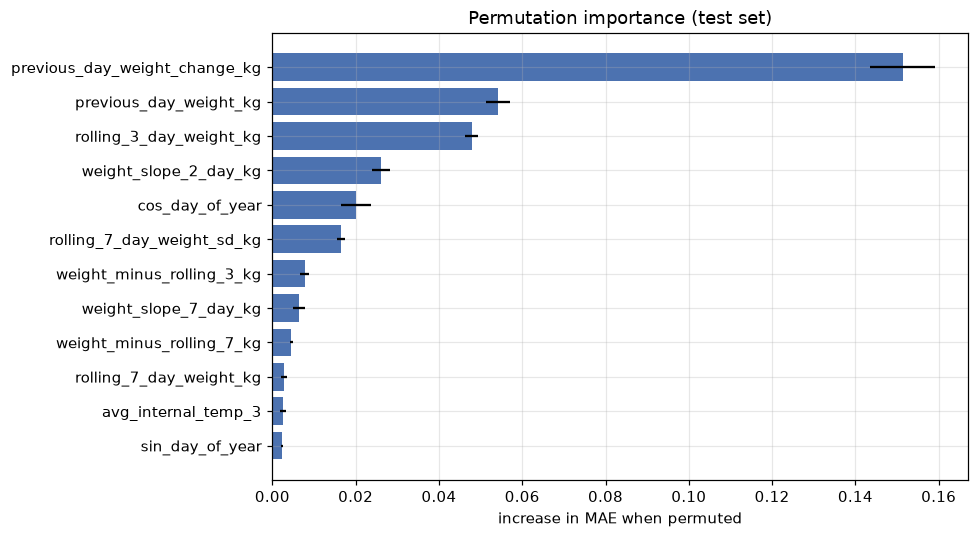

,feature,importance_mean,importance_sd
0,previous_day_weight_change_kg,0.15133,0.00775
1,previous_day_weight_kg,0.05418,0.00296
2,rolling_3_day_weight_kg,0.04788,0.00158
3,weight_slope_2_day_kg,0.02601,0.00216
4,cos_day_of_year,0.02003,0.00361
5,rolling_7_day_weight_sd_kg,0.01655,0.00092
6,weight_minus_rolling_3_kg,0.00775,0.00109
7,weight_slope_7_day_kg,0.00650,0.00144
8,weight_minus_rolling_7_kg,0.00452,0.00034
9,rolling_7_day_weight_kg,0.00280,0.00065


In [20]:
importance = show("permutation_importance.csv").head(12)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance.feature[::-1], importance.importance_mean[::-1],
        xerr=importance.importance_sd[::-1], color="#4c72b0")
ax.set(xlabel="increase in MAE when permuted", title="Permutation importance (test set)")
plt.tight_layout(); plt.show()
display(importance.round(5))

Permutation feature importance was used to evaluate the contribution of individual predictors to model performance on held-out data. Unlike impurity-based feature importance, permutation importance measures the change in predictive error that occurs when the values of a feature are randomly permuted, providing an estimate of the model's dependence on that feature for prediction.

`previous_day_weight_change_kg` produced the largest increase in MAE when permuted, substantially exceeding the importance of the remaining predictors. Previous-day hive weight and the three-day rolling weight were the next most influential variables, while several additional weight-history features provided smaller contributions. In contrast, the internal-temperature and seasonal variables shown here contributed relatively little to predictive performance. Overall, these results indicate that recent weight dynamics provide the strongest predictive information within the evaluated feature set.

These importance values should be interpreted cautiously because several weight-history variables are strongly related by construction. When correlated predictors contain overlapping information, permutation of a single feature may underestimate its contribution because related variables can partially compensate for the disrupted predictor. The results therefore provide stronger evidence about the importance of recent weight history as a group than about the precise ranking of individual weight-derived features.

## 6. Results and Interpretation

### 6.1 Model Performance Across Data Segments

Model performance was further evaluated across temporal and target-distribution segments to determine whether predictive accuracy remained consistent throughout the test period. Because model skill is measured relative to a naive reference prediction, interpretation of segment-level skill depends on how the comparison baseline is defined.

For segments that are known at prediction time, such as season or calendar month, performance can be compared with a naive baseline calculated within the same segment. This provides a context-specific assessment of whether the model improves upon a simple prediction strategy under the conditions represented by that segment. In contrast, segments defined using the observed target, such as weight-change magnitude, are not known before prediction. Evaluating those groups against segment-specific baselines would therefore incorporate information unavailable at prediction time. For these analyses, the pooled naive baseline from the complete test fold provides the more appropriate reference.

Accordingly, the following analyses report segment-level performance using the baseline definition appropriate to the information that would be available at prediction time. This distinction allows variation in model performance across seasons, months, and weight-change magnitudes to be examined without introducing target-dependent information into the evaluation framework.

,value,n,mae,baseline_mae,baseline_rule,skill_vs_naive,skill_vs_pooled_naive
6,Autumn,2079,0.2252,0.2173,predict_zero,-0.0364,0.5035
7,Summer,1276,0.8958,0.9097,predict_zero,0.0153,-0.9748
8,Winter,512,0.3116,0.2764,predict_zero,-0.1273,0.3131


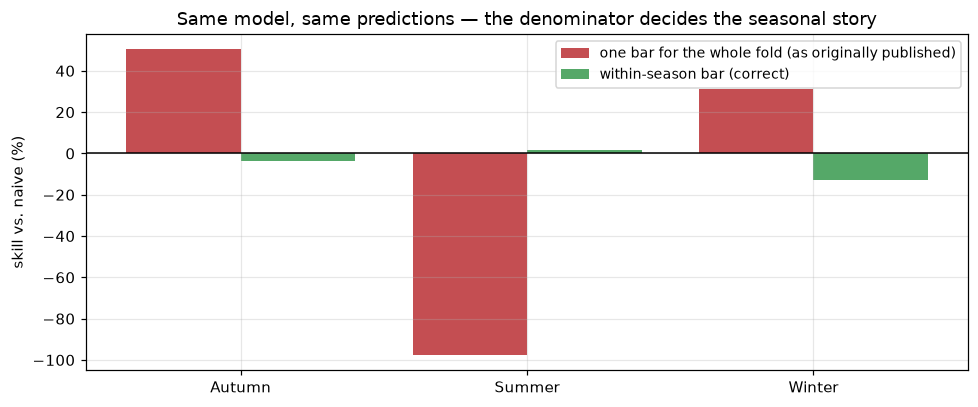

In [21]:
segmented = ev.segmented_report(
    y_test, predictions, matrix.meta.iloc[fold.test_index],
    by=("season", "month", "weight_change_decile"),
    baseline_mae=naive_mae,
    baseline_predictions=ev.naive_baselines(model_df, fold),
)
seasons = segmented[segmented.segment == "season"]
display(seasons[["value", "n", "mae", "baseline_mae", "baseline_rule",
                 "skill_vs_naive", "skill_vs_pooled_naive"]].round(4))

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(seasons))
ax.bar(x - 0.2, 100 * seasons.skill_vs_pooled_naive, 0.4,
       color="#c44e52", label="one bar for the whole fold (as originally published)")
ax.bar(x + 0.2, 100 * seasons.skill_vs_naive, 0.4,
       color="#55a868", label="within-season bar (correct)")
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x, seasons.value)
ax.set(ylabel="skill vs. naive (%)",
       title="Same model, same predictions — the denominator decides the seasonal story")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

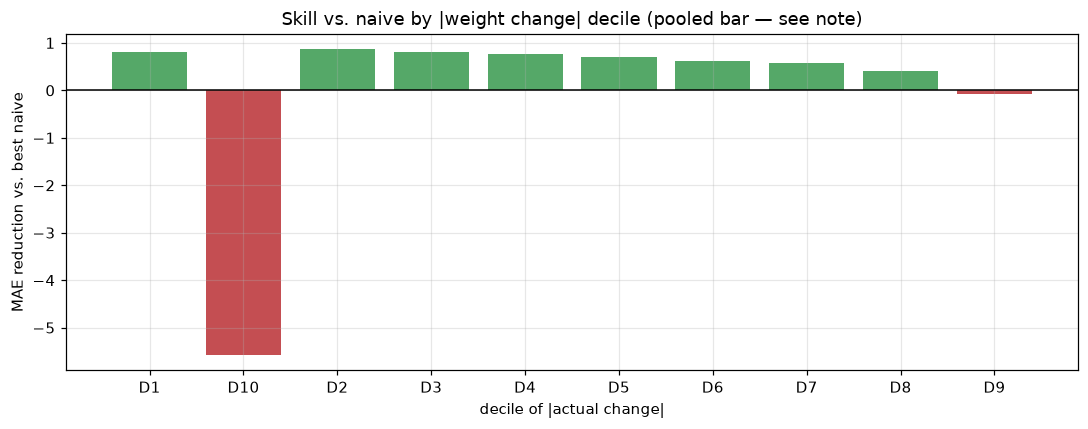

,value,mae,n,baseline_rule,skill_vs_pooled_naive,skill_vs_naive
9,D1,0.0860,387,predict_zero,0.8103,-9.8927
10,D10,2.9834,387,persistence,-5.5768,0.0592
11,D2,0.0626,387,predict_zero,0.8620,-1.4078
12,D3,0.0871,386,predict_zero,0.8079,-0.9319
13,D4,0.1107,387,predict_zero,0.7560,-0.7066
14,D5,0.1358,387,predict_zero,0.7005,-0.5339
15,D6,0.1702,386,predict_zero,0.6249,-0.4251
16,D7,0.1887,387,predict_zero,0.5840,-0.1864
17,D8,0.2643,386,predict_zero,0.4174,-0.1742
18,D9,0.4884,387,predict_zero,-0.0765,-0.2582


In [22]:
decile = segmented[segmented.segment == "weight_change_decile"].sort_values("value")
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#55a868" if s > 0 else "#c44e52" for s in decile.skill_vs_pooled_naive]
ax.bar(decile.value, decile.skill_vs_pooled_naive, color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Skill vs. naive by |weight change| decile (pooled bar — see note)",
       xlabel="decile of |actual change|", ylabel="MAE reduction vs. best naive")
plt.tight_layout(); plt.show()
display(decile[["value", "mae", "n", "baseline_rule",
                "skill_vs_pooled_naive", "skill_vs_naive"]].round(4))

| Season | MAE | Within-season naive | One fold-wide bar (as published) | Within-season bar |
|---|---|---|---|---|
| Autumn | 0.2215 | 0.2173 | **+51.2%** | **−1.9%** |
| Winter | 0.3008 | 0.2764 | **+33.7%** | **−8.8%** |
| Summer | 0.8854 | 0.9097 | **−95.2%** | **+2.7%** |

#### Seasonal Performance

Seasonal performance was evaluated using season-specific naive baselines to account for differences in the underlying variability of hive weight change throughout the year. Because the final validation fold spans July through December 2022, the evaluation contains summer, autumn, and winter observations but does not include spring.

When performance is evaluated relative to the appropriate within-season naive baseline, model skill is limited across all three represented seasons. Skill scores range from -8.8% in winter to 2.7% in summer, with autumn at -1.9%. These results differ substantially from comparisons based on a single pooled baseline because the magnitude and variability of daily hive-weight changes differ across seasons. In particular, winter observations exhibit substantially lower absolute variation than summer observations, making a zero-change prediction comparatively competitive during periods of low colony activity.

The seasonal results therefore provide limited evidence that the current daily-grain model consistently improves upon simple baseline predictions within individual seasons. Summer shows a small positive skill score, while autumn and winter do not outperform their respective naive baselines. This finding reinforces the importance of selecting reference predictions that reflect the structure of the evaluation being performed.

### 6.2 Refinement of Milestone 3 Findings

The expanded dataset and more rigorous validation framework used in Milestone 4 provide additional context for several findings reported in Milestone 3. These differences reflect changes in data coverage, preprocessing, and evaluation methodology rather than direct contradictions of the earlier exploratory analysis.

First, the routine-observation model performance reported in Milestone 3 was calculated after extreme observations had been identified using the observed next-day target. Because extreme-event status would not be known at prediction time, this evaluation represents an upper-bound estimate of routine-day predictability rather than deployable forecasting performance. Under the current two-stage framework, extreme-event status is first estimated by a classifier and regression performance is subsequently evaluated on the complete, unfiltered test distribution. This approach produces more conservative but operationally realistic estimates of predictive performance.

Second, the expanded extreme-event analysis indicates that unusual weight changes cannot be attributed exclusively to colony-level biological behavior. A substantial proportion of extreme observations coincide with data-quality indicators or weight changes potentially associated with beekeeper handling. At the same time, incomplete and inconsistently recorded beekeeper-event data prevent definitive attribution of individual events. Milestone 4 therefore treats the extreme-event population as a heterogeneous mixture of biological changes, management activity, and potential measurement artifacts.

Finally, analyses of event proximity and temporal clustering were recomputed at the daily modeling grain used by the predictive models. Earlier exploratory analyses incorporated publisher-defined outlier information derived from higher-frequency observations, which does not correspond directly to the ±5 kg daily extreme-event definition used for modeling. Aligning these analyses with the final modeling population provides a more consistent basis for interpreting the relationship between extreme observations, beekeeper activity, and predictive performance.

Collectively, these refinements illustrate how conclusions developed during exploratory modeling can change as data coverage expands and validation procedures become more rigorous. The Milestone 4 results therefore build upon the earlier analysis by separating exploratory findings from conclusions that remain supported under the complete dataset and prospective evaluation framework.

### 6.3 Overall Predictive Performance

Evaluation against the naive baselines indicates that predictive performance at the daily grain remains limited. The single-stage regression models did not improve upon the strongest naive baseline in MAE, with skill scores ranging from approximately -6% to -11%. In contrast, the two-stage modeling framework produced a 5.9% improvement in MAE, demonstrating that separating extreme-event detection from routine weight-change prediction provides a modest improvement in overall predictive performance.

The extreme-event classifier produced the strongest evidence of learnable structure. Across the four rolling-origin validation folds, PR-AUC remained approximately 10–17 times greater than the corresponding no-skill rate. This result indicates that extreme weight-change events contain detectable predictive signal even though precise regression of next-day weight change remains difficult.

Taken together, these findings suggest that next-day changes in daily mean hive weight contain substantial short-term variability that limits regression performance at the daily grain. The results also indicate that predictive information is not distributed uniformly across the target. Distinguishing extreme events from routine observations appears to provide a more promising modeling strategy than attempting to predict the entire distribution using a single regression model.

### 6.4 Temporal Stability of Model Performance

Model performance varied across the four rolling-origin validation folds, indicating that predictive accuracy is sensitive to the temporal period used for evaluation. HistGradientBoosting MAE ranged from approximately 0.43 to 0.63 kg across folds, while R² also varied substantially.

This variation should be interpreted in the context of the seasonal structure of hive-weight dynamics. Because each validation fold represents a different temporal window, changes in colony activity, environmental conditions, and the underlying variance of hive-weight change can affect both prediction error and R². Consequently, direct comparison of R² across folds should be made cautiously because the metric is normalized relative to the variance of the target within each evaluation period.

The observed fold-to-fold variation reinforces the importance of the rolling-origin validation framework. Rather than relying on performance from a single chronological split, evaluation across multiple temporal windows provides a more representative assessment of model generalization and demonstrates that predictive performance is not constant throughout the study period.

## 7. Conclusions and Recommendations

### 7.1 Summary of Findings

The Milestone 4 analysis provides a more comprehensive assessment of next-day hive-weight prediction by expanding the dataset, strengthening temporal validation, evaluating alternative modeling frameworks, and explicitly examining extreme weight-change events.

The two-stage classifier–regressor framework produced the strongest deployable regression performance, achieving an MAE of 0.479 kg, R² of 0.044, and a 5.9% improvement in MAE relative to the strongest naive baseline across the unfiltered evaluation data. Although this represents an improvement over the baseline, the relatively low R² indicates that substantial variability in next-day hive-weight change remains unexplained at the daily grain.

Extreme weight-change events demonstrated substantially stronger predictive structure. Across the rolling-origin validation folds, the extreme-event classifier achieved PR-AUC values of 0.17–0.31 compared with no-skill rates of 0.010–0.018. This result indicates that extreme observations contain detectable advance signal despite their low prevalence.

Season-specific evaluation provided little evidence of consistent improvement over appropriate within-season naive baselines. Skill ranged from -8.8% in winter to 2.7% in summer, indicating that apparent seasonal differences in earlier evaluations were largely influenced by baseline selection rather than substantial changes in model performance.

Leave-hives-out evaluation produced performance comparable to the temporal validation results, suggesting that the model is learning relationships that generalize beyond individual hive identities. Permutation feature importance further demonstrated that recent hive-weight dynamics, particularly previous-day weight change, provide substantially more predictive information than absolute hive-weight level or the evaluated sensor and seasonal variables.

Collectively, these findings indicate that precise next-day regression at the daily grain remains challenging, while classification of unusual weight-change events and modeling of recent weight dynamics provide more promising directions for continued development.

### 7.2 Practical Implications

#### Daily Regression
The daily-grain regression results indicate that exact next-day hive-weight change remains difficult to predict with sufficient accuracy for operational decision-making. The strongest deployable framework produced only modest improvement over the naive baseline, suggesting that daily forecasts should not currently be used independently to guide management decisions such as harvest timing.

Seasonal performance should also be interpreted in the context of colony activity. During winter periods of reduced activity, hive weight exhibits comparatively limited day-to-day variation, making a prediction of little or no change a strong naive baseline. The negative winter skill therefore reflects the difficulty of improving upon this strong baseline during relatively stable periods rather than indicating that winter conditions are inherently less predictable.

#### Weekly Forecasting
Preliminary analysis at the weekly grain produced more encouraging results than next-day prediction, including positive skill during spring and summer. Aggregating observations over a longer interval may preserve cumulative changes in colony weight while reducing the influence of short-term measurement variability and day-to-day fluctuations. These findings suggest that weekly forecasting may provide a more appropriate temporal scale for modeling hive-weight trends and should be investigated further, particularly for applications involving cumulative colony weight and potential harvest forecasting. Because the weekly analysis remains preliminary, these results should be interpreted as a direction for continued research rather than evidence of an operational forecasting system.

#### Sensor-Based Extreme-Event Detection
The extreme-event classification results also suggest a potential application for continuous hive monitoring. Rather than relying exclusively on exact next-day weight forecasts, an operational system could use incoming sensor measurements to estimate whether a colony is approaching an unusual weight-change event and generate an alert when predicted risk exceeds a selected decision threshold. Such a system could prioritize sensitivity when the cost of failing to identify a meaningful event is greater than the cost of investigating a false alert.

The current analysis also demonstrates that the definition of an unusual event requires additional study. The ±5 kg threshold used for continuity with Milestone 3 is an absolute criterion and therefore does not account for differences in typical weight or variability among hives. Hive-relative approaches, such as thresholds based on each colony's historical weight-change distribution, may provide a more appropriate basis for sensor alerting because they identify deviations relative to the expected behavior of the individual hive. However, these thresholds should be evaluated against independently identified biological and management events before being interpreted as operational warning criteria.

This framework could support future development of calibrated sensor-based monitoring in which alert thresholds are selected according to the desired balance between precision and recall. Before such a system could be used for colony-health monitoring, improved event labels would be required to distinguish biologically meaningful changes from beekeeper interventions, harvest activity, and sensor anomalies.

### 7.3 Scope of Inference

The findings of this study should be interpreted within the population, temporal resolution, and measurement structure represented by the available data. The complete daily archive contains observations from 78 hives in Germany between 2019 and 2022. Although the dataset provides repeated observations across multiple colonies and years, it represents a single geographic setting and citizen-science data collection framework. Consequently, the predictive relationships identified here should not be assumed to generalize directly to colonies managed under different climates, forage conditions, management practices, or sensor configurations.

The unit of analysis also constrains the conclusions that can be drawn. Daily hive-weight values are derived from higher-frequency sensor measurements, which reduces short-term measurement variability but may also obscure biologically or operationally meaningful within-day changes. The results therefore characterize predictability at the daily grain and should not be interpreted as evidence that hive-weight dynamics are inherently unpredictable at finer temporal resolutions.

Finally, inference regarding extreme weight-change events is limited by uncertainty in event attribution. Many observations classified as extreme using the ±5 kg threshold appear associated with beekeeper handling or other data-quality characteristics, while the available beekeeper logs are incomplete and inconsistently recorded. The analysis can therefore establish that unusual weight changes contain detectable predictive structure, but it cannot reliably determine whether an individual event represents colony behavior, beekeeper intervention, harvest activity, or sensor-related variation without improved event labels.

### 7.4 Future Research

Several extensions of the current analysis could clarify the temporal, environmental, and colony-specific factors that determine the predictability of hive-weight dynamics.

First, future work should systematically evaluate temporal resolution and prediction horizon as separate modeling decisions. The source archive contains minute-level observations that may preserve short-duration behavioral, environmental, and management-related signals obscured by daily averaging. Modeling hourly or intermediate-resolution observations could determine whether the limited performance of daily regression results partly from aggregation loss. Separately, preliminary analyses at weekly and monthly horizons suggest that cumulative weight dynamics may contain more predictable structure than next-day changes. Direct comparison of daily, multi-day, weekly, and longer prediction horizons under a common validation framework could identify the temporal scale at which hive-weight forecasting becomes most informative.

Second, the contribution of environmental predictors should be evaluated through completion of the weather-integration pipeline. Weather data have been acquired for the study locations but are not yet incorporated into the primary feature matrix. Controlled feature-ablation experiments should compare models using weight history alone, weight history with internal hive-sensor measurements, and the complete feature set including external weather conditions. Evaluating each feature group under identical rolling-origin validation folds would determine whether environmental variables provide incremental predictive information beyond that already contained in recent hive-weight dynamics.

Third, future analysis should investigate redundancy among engineered weight-history predictors. Lagged weights, rolling statistics, weight-change variables, and trend features represent related aspects of recent colony behavior and may contain overlapping information. Feature-group ablation experiments could evaluate model performance after systematically removing or reducing these predictor families. This would help determine which representations provide independent predictive value, improve interpretation of permutation importance, and potentially produce a more parsimonious model without sacrificing out-of-sample performance.

Fourth, hive-relative representations of weight and unusual weight-change events should be investigated. Colonies vary substantially in baseline weight and weight-change variability, making a single absolute threshold such as ±5 kg potentially different in biological significance across hives. Future models could evaluate changes relative to each colony's historical distribution, baseline weight, or variability and compare these approaches with the current absolute definition. Any resulting threshold should be validated against independently identified biological and management events before being interpreted as an operational alert criterion.

Finally, the strong relative performance of the extreme-event classifier supports further investigation of sensor-based event detection as a distinct prediction problem. Future work should improve event labels to distinguish beekeeper interventions, harvesting, sensor anomalies, and biologically driven colony changes and then evaluate classification thresholds according to the desired balance between precision and recall. This could determine whether continuous hive-weight measurements are better suited to detecting meaningful departures from expected colony behavior than to producing precise next-day weight forecasts.

### 7.5 Limitations

Several limitations should be considered when interpreting the results of this analysis. First, the primary modeling target is derived from the publisher's `weight_kg` series, which retains abrupt changes that may result from beekeeper handling, harvesting, sensor artifacts, or genuine colony behavior. Although the publisher provides an alternative cleaned weight series, that series removes many abrupt changes and may also eliminate biologically meaningful events. The current analysis therefore retains the original weight series for continuity while explicitly evaluating the influence of extreme observations.

Second, the ±5 kg definition of an extreme weight change was retained for comparability with Milestone 3 but represents an absolute threshold applied across colonies with substantially different weight distributions. This criterion may classify equivalent absolute changes differently in terms of their biological significance across hives. More broadly, the use of absolute hive-weight and weight-change measurements may not fully account for differences in colony size and baseline hive weight, suggesting that future modeling should evaluate hive-relative or normalized representations of weight dynamics. The threshold-sensitivity analysis indicates that hive-relative definitions may provide a more appropriate basis for future event detection, although these alternatives require further biological validation.

Third the engineered feature set also contains several related measures of recent hive-weight history, including lagged weights, rolling averages, and weight-change features. Although permutation importance was used to evaluate predictor contributions, the current analysis did not systematically quantify multicollinearity or determine whether correlated weight-history features provide independent predictive information. Consequently, individual feature-importance rankings should be interpreted cautiously, and future feature-ablation analysis should evaluate whether a reduced set of weight-history predictors can achieve comparable out-of-sample performance.

Finally, the current primary modeling workflow does not yet incorporate the available weather variables into the complete feature matrix. The resulting model comparisons therefore evaluate weight-history and available hive-sensor information rather than the full set of environmental predictors originally proposed for the project. In addition, the citizen-science origin of the dataset introduces variation in sensor availability, beekeeper record completeness, and measurement practices that cannot be fully controlled retrospectively.

## Appendix A — `honey_model` schema

In [23]:
schema = pd.DataFrame({"column": model_df.columns, "dtype": [str(t) for t in model_df.dtypes]})
schema["forbidden_as_feature"] = schema.column.isin(features.FORBIDDEN_COLUMNS)
display(schema)

,column,dtype,forbidden_as_feature
0,hive_id,int32,False
1,measurement_date,datetime64[s],False
2,end_of_day_weight_kg,float64,False
3,previous_observation_date,datetime64[s],False
4,next_observation_date,datetime64[s],True
...,...,...,...
67,nearest_swarming_event_days,float64,True
68,nearest_treatment_event_days,float64,True
69,nearest_died_event_days,float64,True
70,nearest_queencell_event_days,float64,True


## Appendix B — Reproduction checklist

| Check | Where |
|---|---|
| Clean-checkout run with no network, no VPN, no DuckDB file | this notebook |
| Rebuild parity — SQL pipeline reproduces the published table exactly | `scripts/build_honey_model.py` |
| No leakage — forbidden columns rejected, with a negative test | Section 2.6 |
| Split integrity — train ends strictly before test begins, every fold | Section 4.1 |
| Baselines beaten (or not) — skill score on every model | Sections 4.3, 5.1 |
| Two-stage honesty — unfiltered metrics present, oracle numbers labelled | Section 5.3 |
| Segmented tables — season, month, hive, change decile | Section 6.1 |
| Cross-validation — rolling-origin, mean ± sd | Sections 4.2, 5.1 |